# Basic image handling

**Duration** ~45 min &nbsp;·&nbsp; **Session** Day 1, Python notebooks

**This notebook covers**

- what an image *is* to a computer, and how to read its shape and data type
- cropping, slicing and indexing, the same way a list is indexed
- displaying images and channels, and building a composite
- reading a histogram, and using it to choose a threshold
- interactive visualization in the notebook and in **napari**
- turning an image into a binary image, and a binary image into counted objects

**Data**: `data/bbbc020/` field `2h_1`: mouse bone-marrow macrophages, two
channels.
DAPI stains nuclei; CD11b stains the cell surface. These are the same images
segmented in the Fiji practical.

## 1. An image is an array of numbers

**Key properties of a NumPy array:**

| Property | Meaning | Example |
|----------|---------|----------|
| `.shape` | Dimensions (rows, cols, ...) | `(5, 5)` |
| `.dtype` | Data type of elements | `int64`, `uint8`, `float64` |
| `.ndim` | Number of dimensions | `2` |
| `.min()`, `.max()` | Value range | `0`, `255` |

In [1]:
import numpy as np
import tifffile

from course import DATA, show

# The same field you worked on in Fiji.
nuclei = tifffile.imread(DATA / "bbbc020" / "images" / "2h_1_nuclei.tif")

print("type :", type(nuclei))
print("shape:", nuclei.shape)
print("dtype:", nuclei.dtype)
print("range:", nuclei.min(), "to", nuclei.max())

type : <class 'numpy.ndarray'>
shape: (348, 512)
dtype: uint8
range: 0 to 255


Three things to take from that output.

**`shape` is `(rows, columns)`**: 348 rows by 512 columns. Note the order:
height first, then width. This trips up nearly everyone at least once, because
Fiji's status bar reports it the other way round, as *width × height*.

**`dtype` is `uint8`**: an *unsigned 8-bit integer*, so every pixel is a whole
number from 0 to 255. This is the "8-bit" shown in Fiji's `Image ▸ Type` menu.
A 16-bit image (`uint16`) would run 0–65535.

**The image is just a NumPy array.** There is no special image object, so
everything that holds for arrays holds here, and everything in this notebook
transfers to any other numerical data.

In [2]:
# A pixel is one number. Row 187, column 234 lands on background:
print("background pixel (187, 234):", nuclei[187, 234])

# ...and this one lands inside a nucleus.
print("nucleus pixel   (336, 25):", nuclei[336, 25])

background pixel (187, 234): 2
nucleus pixel   (336, 25): 255


## 2. Visualizing an image

### Within the notebook

The simplest way to look at an image is to use `matplotlib.pyplot.imshow()`.

In [2]:
import matplotlib.pyplot as plt

# let's have a look at the `imshow` function to see what arguments it takes
plt.imshow?

Signature:
plt.imshow(
    X: 'ArrayLike | PIL.Image.Image',
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    *,
    aspect: "Literal['equal', 'auto'] | float | None" = None,
    interpolation: 'str | None' = None,
    alpha: 'float | ArrayLike | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    colorizer: 'Colorizer | None' = None,
    origin: "Literal['upper', 'lower'] | None" = None,
    extent: 'tuple[float, float, float, float] | None' = None,
    interpolation_stage: "Literal['data', 'rgba', 'auto'] | None" = None,
    filternorm: 'bool' = True,
    filterrad: 'float' = 4.0,
    resample: 'bool | None' = None,
    url: 'str | None' = None,
    data: 'DataParamType' = None,
    **kwargs,
) -> 'AxesImage'
Docstring:
Display data as an image, i.e., on a 2D regular raster.

The input may either be actual RGB(A) data, or 2D scalar data, which
will be rendered as a pseudocolor image. For displaying a grayscale
im

Text(0.5, 1.0, 'DAPI (nuclei)')

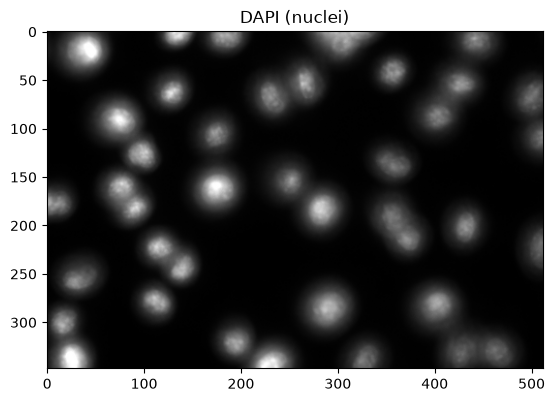

In [20]:
plt.figure()
plt.imshow(nuclei, cmap="gray")
plt.title("DAPI (nuclei)")

`show()` is a small helper defined in `notebooks/course.py`: it calls
matplotlib's `imshow` with a grayscale colormap and no axis ticks, so we do not
repeat those arguments in every cell. It is worth a look; there is nothing magic
in there.

As discussed earlier **the colours on screen are a display
choice, not a property of the data.** The array holds one number per pixel. Matplotlib
maps those numbers to colours using a *colormap*. Fiji calls this a
lookup table (LUT). Changing it changes the picture, not the data.

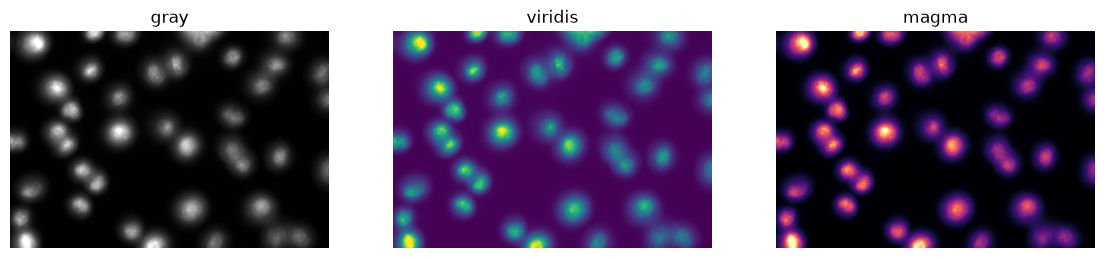

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4)) # this is a way to create a figure with multiple axes (subplots) in one row and three columns
for i in [0, 1, 2]:
    cmap = ["gray", "viridis", "magma"][i]
    axes[i].imshow(nuclei, cmap=cmap)
    axes[i].set_title(cmap)
    axes[i].set_axis_off()

    # with our helper function, we could do the same as above in one line:
    # show(nuclei, title=cmap, ax=axes[i])


### Using napari

Napari is a powerful interactive viewer for multidimensional images.

It is a separate application, but can be called from within a notebook.

In [72]:
import napari

# Let's create a viewer.
# After running this cell, a Napari window will pop up.
viewer = napari.Viewer()

In [ ]:
# Let's add the nuclei image to the viewer

viewer.add_image(nuclei, name="nuclei", colormap="blue")

<Image layer 'nuclei' at 0x37a342050>

We can also take a screenshot of the Napari window and display it in the notebook.

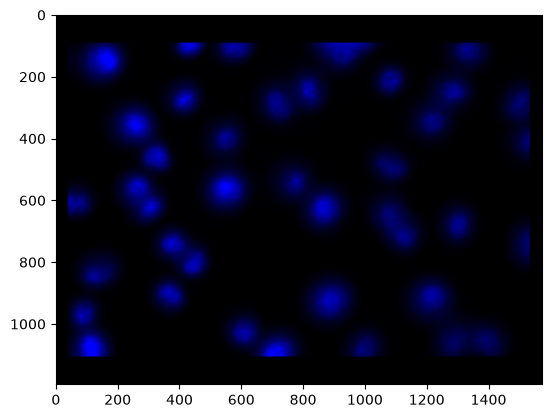

In [79]:
rgb = viewer.screenshot()

plt.imshow(rgb)

In [81]:
# When not needing the viewer anymore, we can close it.

viewer.close()

## 3. Cropping is just indexing

An image is indexed exactly like a nested list: `image[rows, columns]`. A colon
means "all of them", and `start:stop` selects a range.

crop shape: (110, 150)


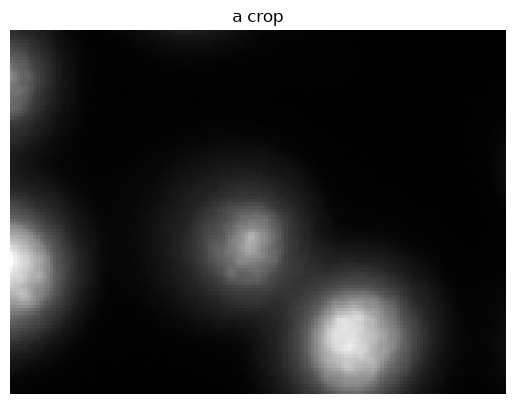

In [21]:
# Rows 90 to 200, columns 180 to 330.
crop = nuclei[90:200, 180:330]
print("crop shape:", crop.shape)

show(crop, title="a crop")

one row: (512,)


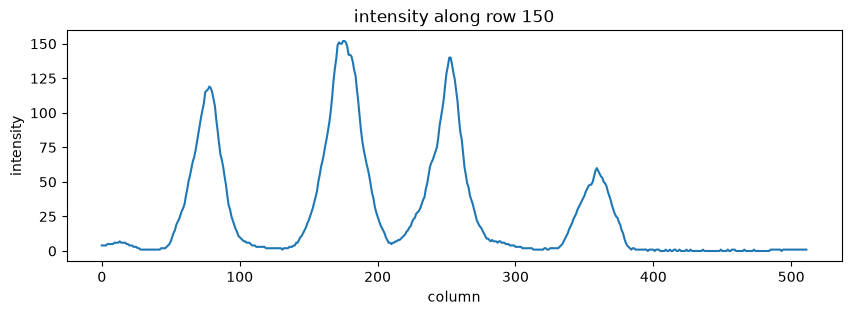

In [23]:
# A single row is a 1D array - similar to Fiji's line profile.
row = nuclei[150, :]
print("one row:", row.shape)

plt.figure(figsize=(10, 3))
plt.plot(row)
plt.xlabel("column")
plt.ylabel("intensity")
plt.title("intensity along row 150")
plt.show()

Every peak in that trace is a bright object the line crossed. This is the same
plot Fiji draws for `Analyze ▸ Plot Profile`, and it is the reason the "how wide
is a filament?" exercise works: measuring the peak's width measures the
object.

## 4. Multichannel images

Let's load the two channels of the BBBC020 image. The DAPI channel is blue, and the CD11b channel is green.

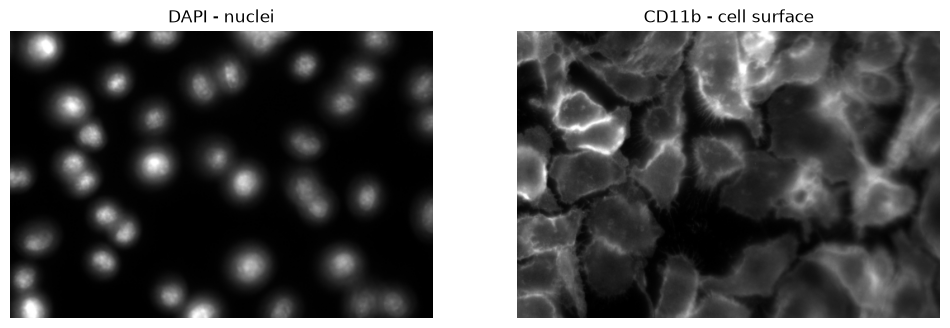

In [25]:
nuclei = tifffile.imread(DATA / "bbbc020" / "images" / "2h_1_nuclei.tif")
cells = tifffile.imread(DATA / "bbbc020" / "images" / "2h_1_cells.tif")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
show(nuclei, title="DAPI - nuclei", ax=axes[0])
show(cells, title="CD11b - cell surface", ax=axes[1])
plt.show()

### Visualizing composite images

#### Option 1: Build an array with three channels, which will be interpreted as RGB.

Each channel is a 2D array, and the composite is a 3D array. The channels will be interpreted as red, green and blue. This limits us to exactly these three channels, but it is the simplest way to make a composite with matplotlib.

Text(0.5, 1.0, 'composite: DAPI (blue) + CD11b (green)')

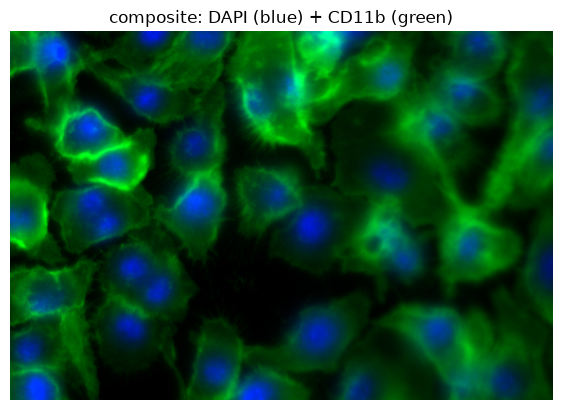

In [29]:
composite = np.zeros((*nuclei.shape, 3), dtype=np.uint8) # create an empty array with the same height and width as the nuclei image, but with 3 channels for RGB
composite[..., 2] = nuclei   # blue channel  <- DAPI
composite[..., 1] = cells    # green channel <- CD11b

plt.figure(figsize=(7, 5))
plt.imshow(composite)
plt.axis("off")
plt.title("composite: DAPI (blue) + CD11b (green)")

#### Option 2: Use a convenience function to make a composite with multiple channels.

In [39]:
from iaf.color import to_composite

# let's have a look at the function definition
to_composite?

Signature:
to_composite(
    images: list[numpy.ndarray],
    colors: list[typing.Union[iaf.color._color.Color, list, tuple]],
    clip_percentile: float = 0.1,
) -> numpy.ndarray
Docstring:
Create a composite image from a series of gray values images and the corresponding colors.

Parameters
----------

images: list[np.ndarray]
    List of gray-value images.

colors: list[Union[Color, list, tuple]]
    List of colors to be used to create a composite. One for each image. Each color is a `Color`, `list` or
    `tuple` with values for `(R, G, B)` between 0.0 and 1.0

clip_percentile: float
    Percentile to clip intensity in the low and high parts of the dynamic range.

Returns
-------

composite: np.ndarray
    RGB composite image
File:      ~/teaching/lab_course/scu_lab_course_ia_test/.pixi/envs/default/lib/python3.11/site-packages/iaf/color/_color.py
Type:      function

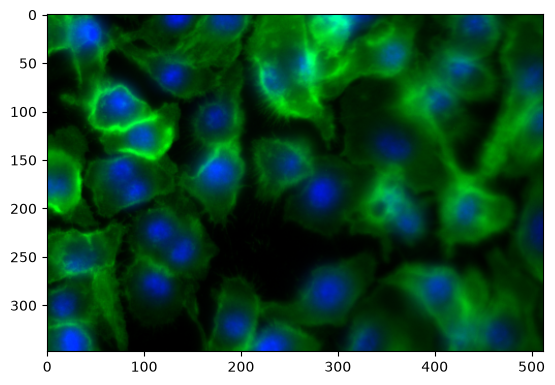

In [47]:
rgb = to_composite(
    [nuclei, cells],
    colors=[(0, 0, 1), (0, 1, 0)]) # blue and green expressed as RGB

plt.imshow(rgb)

### Using napari

When choosing `blending="additive"` we can see multiple channels at once in Napari.
This is the same as Fiji's `Image ▸ Color ▸ Merge Channels…` with "Color" set to "Composite".

In [ ]:
viewer = napari.Viewer()

viewer.add_image(nuclei, name="nuclei", colormap="blue", blending="additive")
viewer.add_image(cells, name="cells", colormap="green", blending="additive")

<Image layer 'cells' at 0x33f80cb90>

In [85]:
viewer.close()

## 5. The histogram

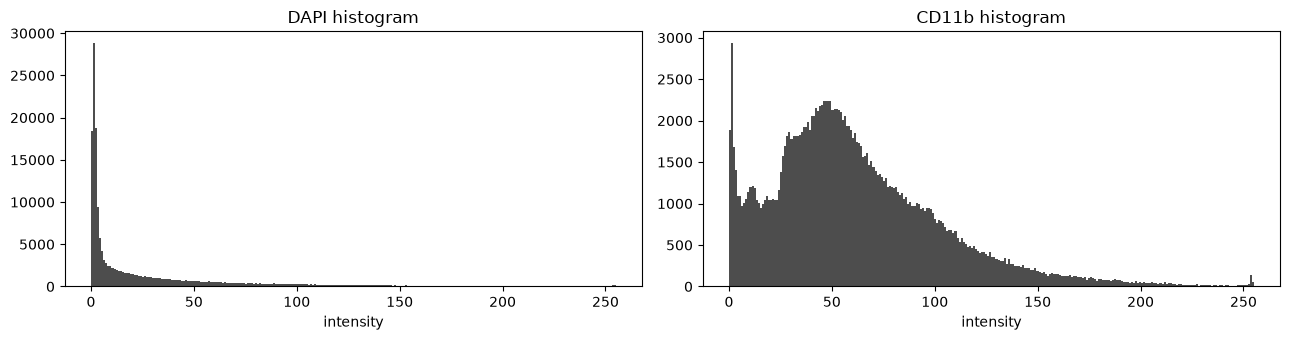

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, img, name in zip(axes, [nuclei, cells], ["DAPI", "CD11b"]):
    ax.hist(img.ravel(), bins=256, range=(0, 255), color="0.3")
    # ax.set_yscale("log")
    ax.set_title(f"{name} histogram")
    ax.set_xlabel("intensity")
plt.tight_layout()
plt.show()

The histogram counts how many pixels hold each intensity. Note the log scale on
the y-axis: without it the background peak is so tall that everything else is
invisible.

Both histograms have a large spike near zero: that is background, and most of the
image is background. To the right of it sits a long tail of brighter pixels: the
objects. **Thresholding is the act of drawing a line between those two parts.**

## 6. From intensity image to binary image: semantic segmentation

In [ ]:
# A threshold produces a boolean array: True where the condition holds.
mask = nuclei > 60

print("mask dtype:", mask.dtype)

mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(348, 512))

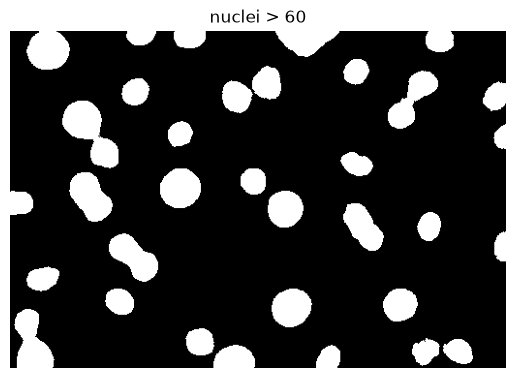

In [90]:
# Visualizing the mask is straightforward

show(mask, title="nuclei > 60")
plt.show()

`nuclei > 60` compares every pixel at once and returns an array of `True`/`False`
: a **mask**. This is Fiji's `Image ▸ Adjust ▸ Threshold…` with the slider at 60,
and picking that number by hand is just as arbitrary here as it was there.

Otsu's method picks the threshold automatically, by finding the value that best
separates the histogram into two groups.

Otsu threshold: 61


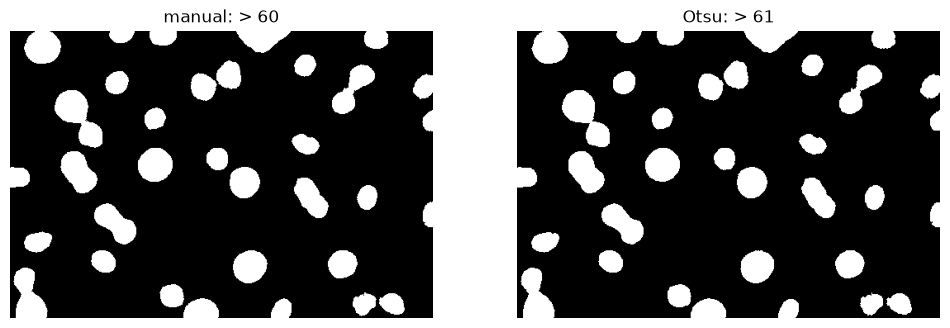

In [91]:
from skimage.filters import threshold_otsu

t = threshold_otsu(nuclei)
print("Otsu threshold:", t)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show(nuclei > 60, title="manual: > 60", ax=axes[0])
show(nuclei > t, title=f"Otsu: > {t}", ax=axes[1])
plt.show()

## 7. From binary image to objects: connected component labeling

Or: **Semantic segmentation** (binary image) vs **Instance segmentation** (label image).

In [97]:
from skimage.measure import label

labels = label(nuclei > t)
print("objects found:", labels.max())

# A label image is NOT a binary image: pixel values are object numbers.
print("label image dtype:", labels.dtype, "| values 0 to", labels.max())

objects found: 34
label image dtype: int32 | values 0 to 34


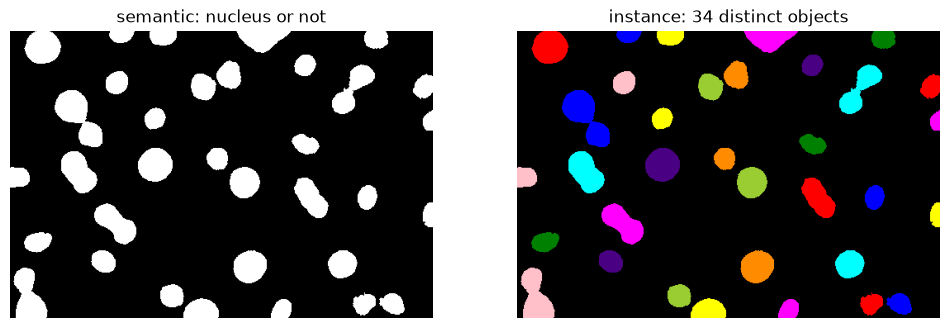

In [118]:
# this function is a helper to visualize label images
from skimage.color import label2rgb

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

show(nuclei > t, title="semantic: nucleus or not", ax=axes[0])
# show(labels, title=f"instance: {labels.max()} distinct objects", ax=axes[1])
show(label2rgb(labels, bg_label=0), title=f"instance: {labels.max()} distinct objects", ax=axes[1])

*Limitation*: **Connected components cannot separate objects that touch.**

In the next notebook we will see a second way of getting from a semantic segmentation to an instance segmentation, which can separate touching objects.

In [121]:
# napari opens a separate window with more tools - useful for anything 3D or
# multi-channel. Run this cell yourself; it is skipped when the website is built.
import napari

viewer = napari.Viewer()
viewer.add_image(nuclei, name="DAPI", colormap="blue", blending="additive")
viewer.add_image(cells, name="CD11b", colormap="green", blending="additive")

# notice that we add labels using "add_labels" and not "add_image":
# Napari knows that this is a label image and will treat it differently than a regular image.
viewer.add_labels(labels, name="nuclei labels")

<Labels layer 'nuclei labels' at 0x3439f5f10>

### Different kinds of images

These names are used consistently across the bioimage analysis literature, and
the differences between them matter for the rest of the course.

| | what a pixel holds | answers | dtype |
|---|---|---|---|
| **intensity image** | a measured brightness | how much signal is here? | integer or float |
| **binary image** | one of two values | is this pixel foreground? | `bool`, or 0 and 255 |
| **label image** | an object number | *which* object is this pixel in? | integer |

Note: We can use a binary image to *select* pixels from another image, as in `image[binary]`.

## Recap

These steps correspond to operations from the Fiji practical:

| Fiji | Python |
|---|---|
| open an image | `tifffile.imread(...)` |
| `Image ▸ Type` | `image.dtype` |
| rectangle + `Image ▸ Crop` | `image[90:200, 180:330]` |
| `Analyze ▸ Plot Profile` | `plt.plot(image[150, :])` |
| `Merge Channels…` | assign into an RGB array |
| `Analyze ▸ Histogram` | `plt.hist(image.ravel(), bins=256)` |
| `Adjust ▸ Threshold…` | `image > t`: a semantic segmentation |
| `Analyze Particles…` | `label(mask)`: connected component labeling, an instance segmentation |

Two ideas to carry forward, because everything from here builds on them:

- **semantic** segmentation labels pixels by class; **instance** segmentation
  labels them by object;
- **connected component labeling** turns the first into the second, and fails
  exactly when objects touch.

Next: `02_image_processing` covers preprocessing and watershed segmentation for
touching objects.